# Notebook 3 (Publication Edition): Strain-Specific Capability Analysis

This notebook is the publication-ready integration of the final plotting workflow.
It keeps the original computational logic unchanged and standardizes documentation in English.

Main modules:
1. Baseline FBA and flux export
2. Formate-light scanning with heatmaps and linear regression
3. dFBA cell-factory simulation (lycopene route)
4. Pie chart generation and pie-chart workflow flowchart


## Inputs / Outputs

### Input model
- `../Models/purple_bacteriav_DSM123.json` (final curated model)

### Output directory
- `publication_outputs/`

### Core generated files
- `flux_full.csv` / `flux_exchange_nonzero.csv`
- `Heatmap_Growth_Rate.svg`
- `Heatmap_Carbon_Efficiency.svg`
- `Analysis_Linear_Regression.svg`
- `dFBA_CellFactory_Lycopene.svg`
- `dFBA_CellFactory_Summary.csv`
- `Carbon_Partition_Pie_Average.svg`


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

# Keep cobrapy cache inside current workspace to avoid system path permission errors
WORKSPACE_COBRA_CACHE = Path('.cobrapy_cache')
WORKSPACE_COBRA_CACHE.mkdir(parents=True, exist_ok=True)
import appdirs
appdirs.user_cache_dir = lambda *args, **kwargs: str(WORKSPACE_COBRA_CACHE.resolve())

import cobra
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib import rcParams
from matplotlib.patches import FancyBboxPatch
from IPython.display import display

# --- Global style (publication-oriented) ---
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = 'Arial'
rcParams['mathtext.it'] = 'Arial:italic'
rcParams['mathtext.bf'] = 'Arial:bold'
rcParams['axes.unicode_minus'] = False

MODEL_JSON = Path('../Models/purple_bacteriav_DSM123.json')
OUTPUT_DIR = Path('publication_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

assert MODEL_JSON.exists(), f'Model file not found: {MODEL_JSON}'
print(f'Model: {MODEL_JSON.resolve()}')
print(f'Output dir: {OUTPUT_DIR.resolve()}')


Model: D:\Project\ai_project\DSM123\old\plot_notebook\../Models/purple_bacteriav_DSM123.json
Output dir: D:\Project\ai_project\DSM123\old\plot_notebook\publication_outputs


In [2]:

# ---------- Shared model setup ----------

def apply_base_medium(model, oxygen_lb=-0.1, formate_bounds=(-1000.0, 1000.0), photon_lb=-1000.0):
    """Apply base physicochemical constraints used across analyses."""
    for ex in model.exchanges:
        ex.lower_bound = 0.0

    essential_ions = [
        'EX_cobalt2_e', 'EX_zn2_e', 'EX_so4_e', 'EX_ca2_e', 'EX_mn2_e',
        'EX_mg2_e', 'EX_cu2_e', 'EX_k_e', 'EX_fe3_e', 'EX_mobd_e',
        'EX_na1_e', 'EX_cl_e', 'EX_bo3_e', 'EX_pi_e', 'EX_h2o_e', 'EX_h_e', 'EX_nh4_e'
    ]
    for ion in essential_ions:
        if ion in model.reactions:
            model.reactions.get_by_id(ion).lower_bound = -1000.0

    if 'EX_co2_e' in model.reactions:
        model.reactions.get_by_id('EX_co2_e').bounds = (-1000.0, 1000.0)
    if 'EX_o2_e' in model.reactions:
        model.reactions.get_by_id('EX_o2_e').bounds = (oxygen_lb, 1000.0)
    if 'EX_for_e' in model.reactions:
        model.reactions.get_by_id('EX_for_e').bounds = formate_bounds
    if 'NTRSA' in model.reactions:
        model.reactions.get_by_id('NTRSA').bounds = (0.0, 0.0)
    if 'EX_photon_purple_e' in model.reactions:
        model.reactions.get_by_id('EX_photon_purple_e').bounds = (photon_lb, 0.0)

    # Prevent shortcut fluxes used in previous notebooks
    if 'POR5' in model.reactions:
        model.reactions.get_by_id('POR5').lower_bound = 0.0
    if 'ME2' in model.reactions:
        model.reactions.get_by_id('ME2').lower_bound = 0.0

    return model


def ensure_lycopene_demand(model):
    """Add demand reaction DM_lycop_c if lycopene metabolite exists."""
    try:
        lycop = model.metabolites.get_by_id('lycop_c')
        if 'DM_lycop_c' not in model.reactions:
            model.add_boundary(lycop, type='demand')
    except KeyError:
        print('Warning: lycop_c not found in model, DM_lycop_c not added.')
    return model


## 1) Baseline FBA and Flux Export

In [3]:

model = cobra.io.load_json_model(str(MODEL_JSON))
model = apply_base_medium(model, oxygen_lb=-0.1, formate_bounds=(-20.0, 1000.0), photon_lb=-1000.0)
solution = model.optimize()

flux_df = solution.to_frame().reset_index().rename(columns={'index': 'reaction_id'})
flux_df.to_csv(OUTPUT_DIR / 'flux_full.csv', index=False, encoding='utf-8-sig')

exchange_df = flux_df[
    flux_df['reaction_id'].str.startswith('EX_') & (flux_df['fluxes'].abs() > 1e-9)
].sort_values('fluxes', ascending=False)
exchange_df.to_csv(OUTPUT_DIR / 'flux_exchange_nonzero.csv', index=False, encoding='utf-8-sig')

print(f'Objective value (growth): {solution.objective_value:.6f}')
display(exchange_df.head(20))


Objective value (growth): 0.447596


,reaction_id,fluxes,reduced_costs
430,EX_h2o_e,1.448874e+01,0.000000e+00
432,EX_co2_e,1.054401e+01,0.000000e+00
478,EX_pi_e,1.632266e-01,0.000000e+00
451,EX_mobd_e,-9.796930e-09,0.000000e+00
447,EX_cu2_e,-1.350811e-08,0.000000e+00
2084,EX_bo3_e,-1.632741e-08,0.000000e+00
453,EX_na1_e,-5.326394e-08,-1.016319e-09
442,EX_mn2_e,-7.879776e-08,0.000000e+00
435,EX_zn2_e,-3.293191e-07,0.000000e+00
448,EX_k_e,-6.924312e-07,0.000000e+00


## 2) Formate-Light Scan (Heatmaps + Linear Regression)


In [3]:
def l9(model):
    """Apply baseline environmental medium and reaction constraints."""
    for ex in model.exchanges:
        ex.lower_bound = 0.0
    essential_ions = [
        'EX_cobalt2_e', 'EX_zn2_e', 'EX_so4_e', 'EX_ca2_e', 'EX_mn2_e',
        'EX_mg2_e', 'EX_cu2_e', 'EX_k_e', 'EX_fe3_e', 'EX_mobd_e',
        'EX_na1_e', 'EX_cl_e', 'EX_bo3_e', 'EX_pi_e', 'EX_h2o_e', 'EX_h_e', 'EX_nh4_e'
    ]
    for ion in essential_ions:
        if ion in model.reactions:
            model.reactions.get_by_id(ion).lower_bound = -1000.0

    if "EX_co2_e" in model.reactions:
        model.reactions.get_by_id("EX_co2_e").bounds = (-1000.0, 1000.0)
    if "EX_o2_e" in model.reactions:
        model.reactions.get_by_id("EX_o2_e").bounds = (-1.0, 1000.0)
    if "EX_for_e" in model.reactions:
        model.reactions.get_by_id("EX_for_e").bounds = (-1000.0, 1000.0)
    if "NTRSA" in model.reactions:
        model.reactions.get_by_id("NTRSA").bounds = (0, 0.0)
    if "EX_photon_purple_e" in model.reactions:
        model.reactions.get_by_id("EX_photon_purple_e").bounds = (-1000.0, 0.0)

    if "POR5" in model.reactions:
        model.reactions.get_by_id("POR5").lower_bound = 0.0
    if "ME2" in model.reactions:
        model.reactions.get_by_id("ME2").lower_bound = 0.0
    return model


def run_fba_and_save(model_file=MODEL_JSON, output_dir=OUTPUT_DIR, force=False):
    """Run the FBA scan and save reusable matrix files."""
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)
    biomass_path = output_dir / "res_biomass.npy"
    efficiency_path = output_dir / "res_efficiency.npy"
    ranges_path = output_dir / "ranges.npy"

    if biomass_path.exists() and efficiency_path.exists() and ranges_path.exists() and not force:
        print(">>> Existing scan matrices detected; skipping FBA matrix calculation.")
        return

    print(">>> Starting FBA matrix calculation on a 50x50 grid...")
    try:
        model = cobra.io.load_json_model(str(model_file))
    except Exception as exc:
        print(f"ERROR: Could not load model file {model_file}. Details: {exc}")
        return

    model = l9(model)

    grid_size = 100
    formate_range = np.linspace(1, 12, grid_size)
    light_range = np.linspace(1, 65, grid_size)

    res_biomass = np.zeros((grid_size, grid_size))
    res_efficiency = np.zeros((grid_size, grid_size))

    print(">>> Running high-speed FBA optimization...")
    for i, for_val in enumerate(formate_range):
        if i % 10 == 0:
            print(f"   -> Progress: row {i}/50")
        with model as m:
            m.reactions.get_by_id("EX_for_e").lower_bound = -for_val
            for j, light_val in enumerate(light_range):
                m.reactions.get_by_id("EX_photon_purple_e").lower_bound = -light_val

                obj_val = m.slim_optimize()

                if obj_val > 1e-6:
                    sol = m.optimize()
                    res_biomass[i, j] = sol.objective_value
                    v_fdh = sol.fluxes["FDH"] if "FDH" in sol.fluxes else 0.0
                    v_rbpc = sol.fluxes["RBPC"] if "RBPC" in sol.fluxes else 0.0
                    res_efficiency[i, j] = v_rbpc / v_fdh if v_fdh > 1e-6 else 0.0

    np.save(biomass_path, res_biomass)
    np.save(efficiency_path, res_efficiency)
    np.save(ranges_path, {"formate": formate_range, "light": light_range})
    pd.DataFrame(res_biomass, index=formate_range, columns=light_range).to_csv(
        output_dir / "res_biomass_matrix.csv", encoding="utf-8-sig"
    )
    pd.DataFrame(res_efficiency, index=formate_range, columns=light_range).to_csv(
        output_dir / "res_efficiency_matrix.csv", encoding="utf-8-sig"
    )
    print(">>> Matrix calculation complete; local .npy and .csv files were saved.")


def analyze_and_plot_extended(output_dir=OUTPUT_DIR):
    """Load scan matrices, fit the stoichiometric line, and save three SVG figures."""
    output_dir = Path(output_dir)
    print(">>> Loading scan matrices and running extended analysis...")

    try:
        res_biomass = np.load(output_dir / "res_biomass.npy")
        res_efficiency = np.load(output_dir / "res_efficiency.npy")
        ranges = np.load(output_dir / "ranges.npy", allow_pickle=True).item()
    except Exception as exc:
        print(f"ERROR: Could not load scan matrix files. Run the calculation module first. Details: {exc}")
        return

    formate_range = ranges["formate"]
    light_range = ranges["light"]
    grid_size = len(formate_range)

    label_units = r"($\mathrm{mmol\ gDCW}^{-1} \mathrm{h}^{-1}$)"
    common_mask = (res_biomass < 0.001)

    inflection_lights = []
    valid_formates = []

    for i in range(grid_size):
        row_data = res_biomass[i, :]
        max_val = np.max(row_data)
        if max_val < 0.01:
            continue
        idx = np.where(row_data >= 0.99 * max_val)[0][0]
        inflection_lights.append(light_range[idx])
        valid_formates.append(formate_range[i])

    slope, intercept, r_value, p_value, std_err = stats.linregress(inflection_lights, valid_formates)
    r_squared = r_value**2

    print("-" * 40)
    print("Statistical report (Stoichiometric Line):")
    print(f"  Equation: Formate = {slope:.5f} * Light + {intercept:.5f}")
    print(f"  R-squared: {r_squared:.5f}")
    print("-" * 40)

    pd.DataFrame({
        "light_inflection": inflection_lights,
        "formate_at_inflection": valid_formates,
    }).to_csv(output_dir / "Stoichiometric_Inflection_Points.csv", index=False)

    def create_publication_figure():
        tick_indices = np.linspace(0, grid_size - 1, 6).astype(int)
        x_labels_phys = [int(light_range[idx]) for idx in tick_indices]
        y_labels_phys = [int(formate_range[idx]) for idx in tick_indices]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

        sns.heatmap(
            res_biomass,
            ax=ax1,
            cmap="RdBu_r",
            mask=common_mask,
            cbar_kws={'label': r'Growth Rate ($\mathrm{h}^{-1}$)'},
        )
        ax1.set_title("Growth Rate Scan", fontsize=18, fontweight='bold', pad=20)

        sns.heatmap(
            res_efficiency,
            ax=ax2,
            cmap="RdBu_r",
            mask=common_mask,
            cbar_kws={'label': 'RBPC / FDH Ratio'},
        )
        ax2.set_title("Carbon Conversion Efficiency", fontsize=18, fontweight='bold', pad=20)

        for ax in [ax1, ax2]:
            ax.set_xlabel(f"Light Uptake {label_units}", fontsize=13)
            ax.set_ylabel(f"Formate Uptake {label_units}", fontsize=13)
            ax.set_xticks(tick_indices + 0.5)
            ax.set_yticks(tick_indices + 0.5)
            ax.set_xticklabels(x_labels_phys, rotation=0)
            ax.set_yticklabels(y_labels_phys, rotation=0)
            ax.invert_yaxis()

        plt.tight_layout()
        return fig, ax1, ax2, tick_indices, x_labels_phys, y_labels_phys

    print(">>> Drawing figure 1: standalone fitted stoichiometric line analysis...")
    plt.figure(figsize=(10, 8))
    plt.scatter(inflection_lights, valid_formates, color='red', label='Stoichiometric Inflection Points', alpha=0.6)

    fit_x_vals = np.array([min(inflection_lights), max(inflection_lights)])
    plt.plot(
        fit_x_vals,
        slope * fit_x_vals + intercept,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Stoichiometric Line (Linear Fit)',
    )

    plt.title("Stoichiometric Line Fit Analysis", fontsize=18, fontweight='bold', pad=20)
    plt.xlabel(f"Light Uptake {label_units}", fontsize=14, fontweight='bold')
    plt.ylabel(f"Formate Uptake {label_units}", fontsize=14, fontweight='bold')

    equation = f"$Formate = {slope:.4f} \cdot Light + {intercept:.4f}$"
    r2_text = f"$\mathit{{R}}^{{2}} = {r_squared:.4f}$"
    plt.text(0.05, 0.95, f"{equation}\n{r2_text}", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

    plt.tight_layout()
    plt.savefig(output_dir / "Scan_Analysis_FitLine.svg", format='svg', bbox_inches='tight')
    plt.show()

    print(">>> Drawing figure 2: two-panel heatmap without fitted line...")
    fig_no_line, _, _, _, _, _ = create_publication_figure()
    plt.tight_layout()
    plt.savefig(output_dir / "Scan_Analysis_Final_NoLine.svg", format='svg', bbox_inches='tight')
    print(">>> Vector scan analysis report generated without fitted line.")
    plt.show()

    print(">>> Drawing figure 3: two-panel heatmap with fitted line...")
    fig_with_line, _, ax2_with_line, _, _, _ = create_publication_figure()

    fit_x_indices = (np.array(inflection_lights) - light_range[0]) / (light_range[1] - light_range[0])
    fit_y_indices = ((slope * np.array(inflection_lights) + intercept) - formate_range[0]) / (formate_range[1] - formate_range[0])

    ax2_with_line.plot(
        fit_x_indices + 0.5,
        fit_y_indices + 0.5,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Stoichiometric Limit Line',
    )

    plt.tight_layout()
    plt.savefig(output_dir / "Scan_Analysis_Final.svg", format='svg', bbox_inches='tight')
    print(">>> Vector scan analysis report generated with fitted line.")
    plt.show()

    return slope, intercept, r_squared, p_value



<>:191: SyntaxWarning: invalid escape sequence '\c'
<>:192: SyntaxWarning: invalid escape sequence '\m'
<>:191: SyntaxWarning: invalid escape sequence '\c'
<>:192: SyntaxWarning: invalid escape sequence '\m'
C:\Users\pc\AppData\Local\Temp\ipykernel_45812\2664972728.py:191: SyntaxWarning: invalid escape sequence '\c'
  equation = f"$Formate = {slope:.4f} \cdot Light + {intercept:.4f}$"
C:\Users\pc\AppData\Local\Temp\ipykernel_45812\2664972728.py:192: SyntaxWarning: invalid escape sequence '\m'
  r2_text = f"$\mathit{{R}}^{{2}} = {r_squared:.4f}$"


>>> Starting FBA matrix calculation on a 50x50 grid...
>>> Running high-speed FBA optimization...
   -> Progress: row 0/50
   -> Progress: row 10/50
   -> Progress: row 20/50
   -> Progress: row 30/50
   -> Progress: row 40/50
   -> Progress: row 50/50
   -> Progress: row 60/50
   -> Progress: row 70/50
   -> Progress: row 80/50
   -> Progress: row 90/50
>>> Matrix calculation complete; local .npy and .csv files were saved.
>>> Loading scan matrices and running extended analysis...
----------------------------------------
Statistical report (Stoichiometric Line):
  Equation: Formate = 0.19686 * Light + -0.06623
  R-squared: 0.99987
----------------------------------------
>>> Drawing figure 1: standalone fitted stoichiometric line analysis...


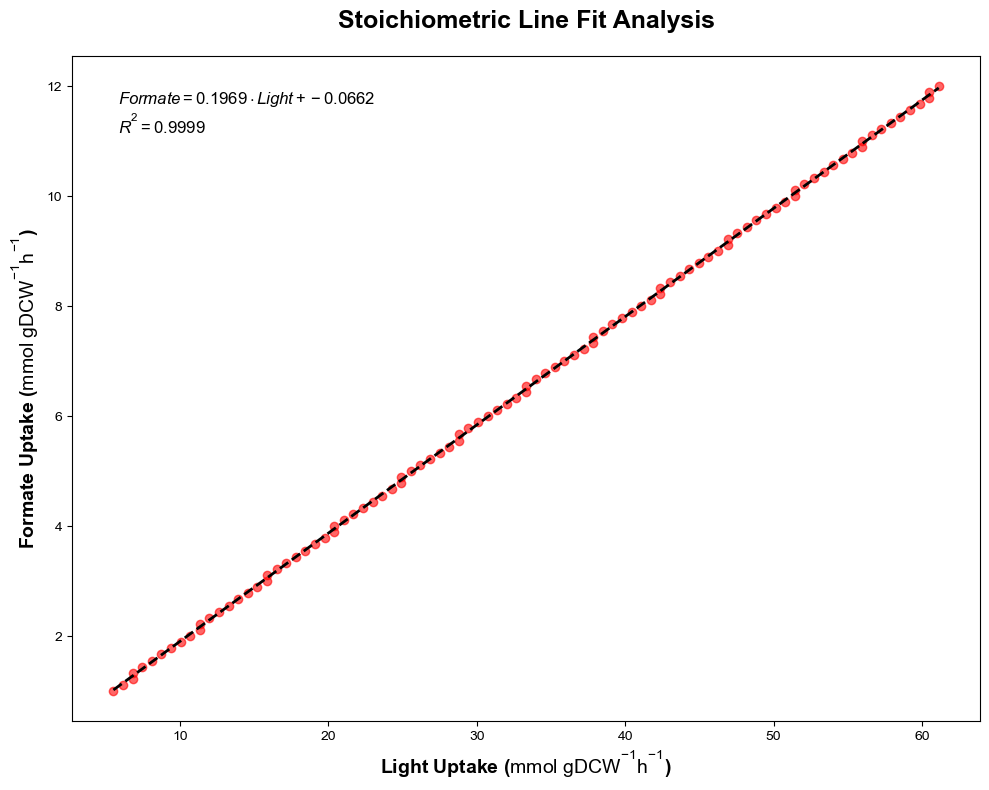

>>> Drawing figure 2: two-panel heatmap without fitted line...
>>> Vector scan analysis report generated without fitted line.


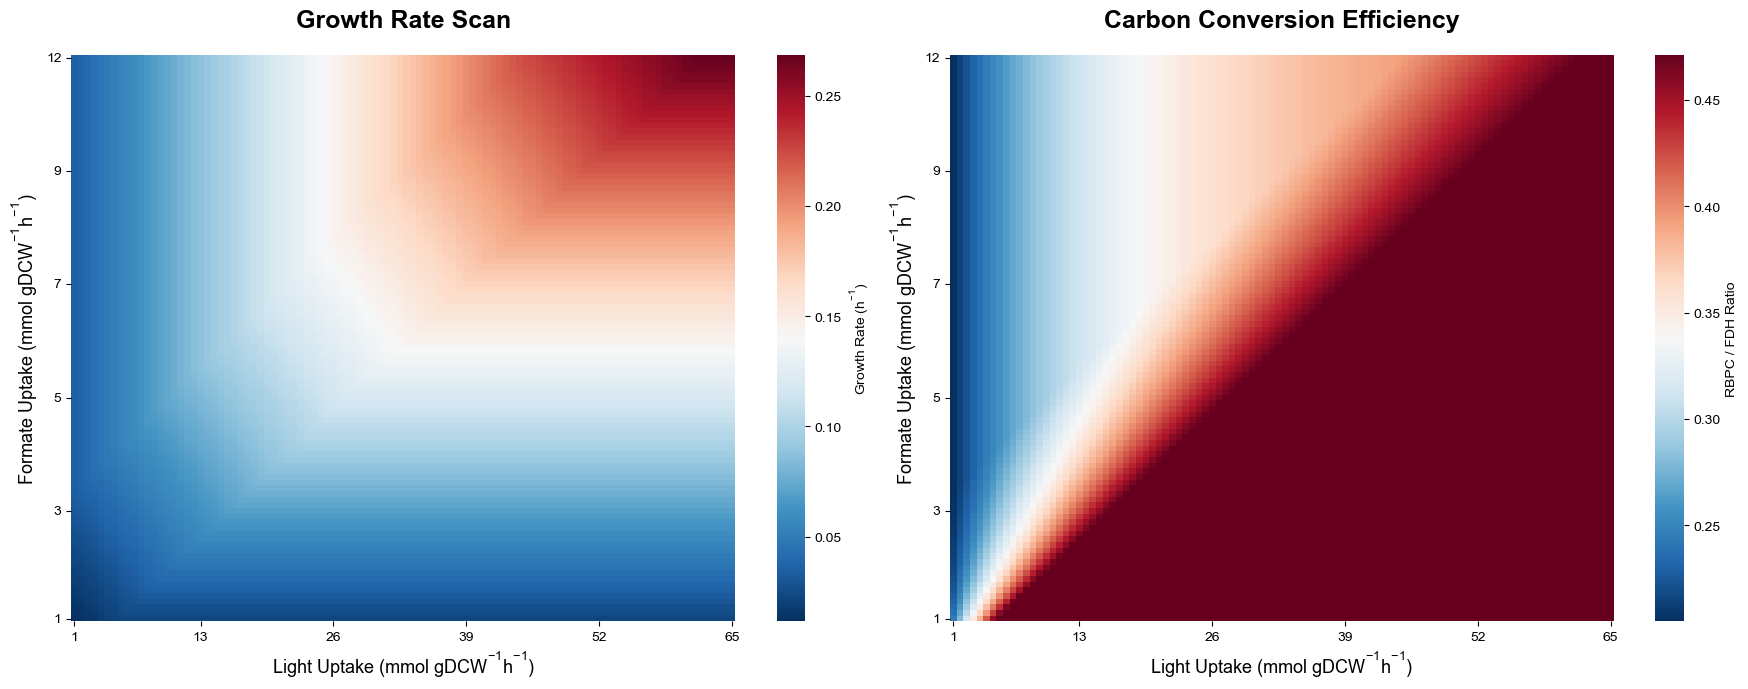

>>> Drawing figure 3: two-panel heatmap with fitted line...
>>> Vector scan analysis report generated with fitted line.


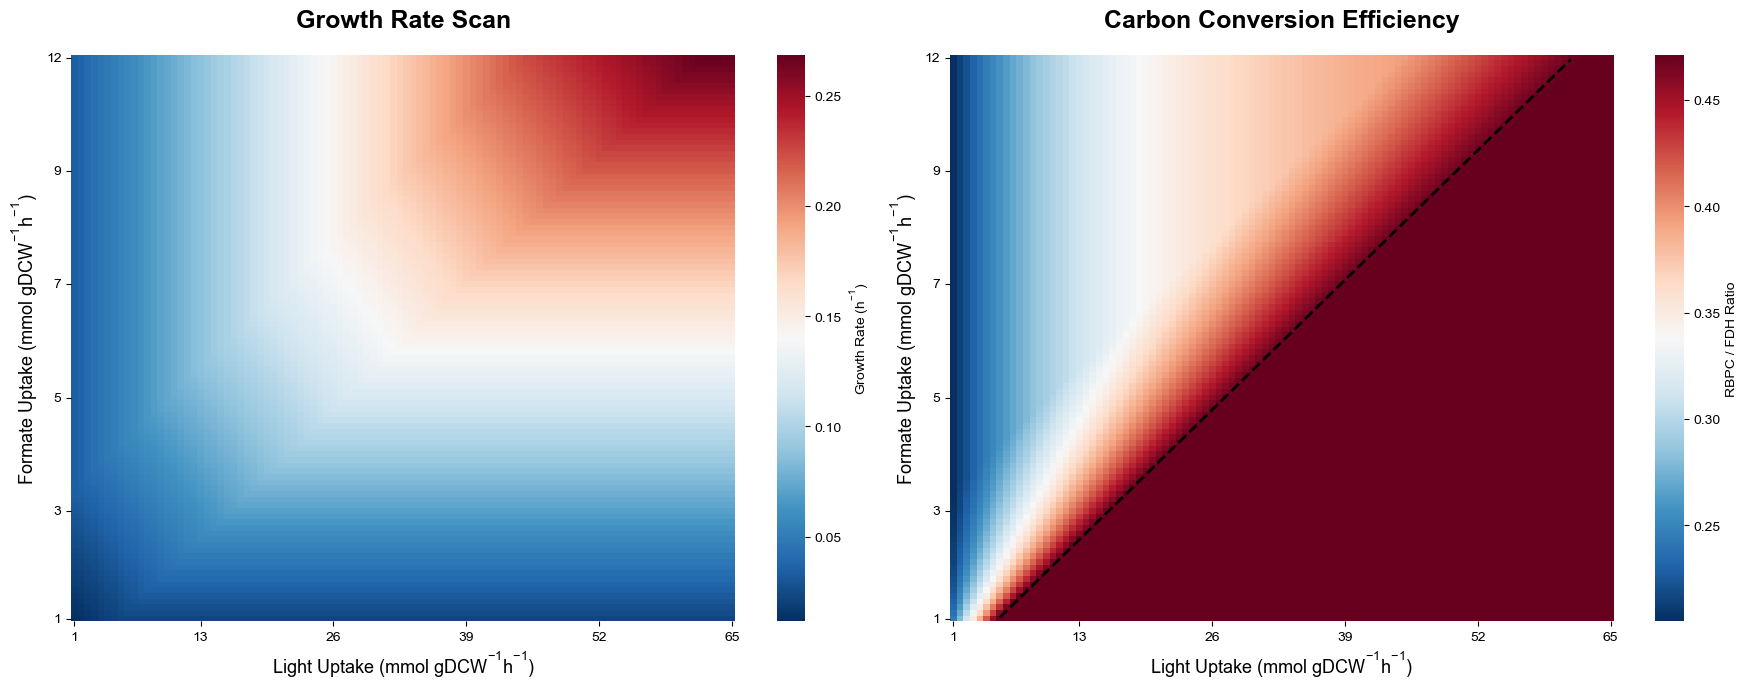

Scan analysis complete: Formate = 0.19686 * Light + (-0.06623), R^2=0.99987, p=1.21e-191


In [4]:
run_fba_and_save(MODEL_JSON, OUTPUT_DIR, force=True)
scan_slope, scan_intercept, scan_r_squared, scan_p_value = analyze_and_plot_extended(OUTPUT_DIR)
print(
    f"Scan analysis complete: Formate = {scan_slope:.5f} * Light + ({scan_intercept:.5f}), "
    f"R^2={scan_r_squared:.5f}, p={scan_p_value:.3g}"
)



## 3) dFBA Cell Factory Simulation (Lycopene Route)

### dFBA Hyperparameters (Editable)
Edit this dictionary before running to test different dFBA settings.


In [6]:
DFBA_PARAMS = {
    'initial_formates': (5, 10, 15, 20),
    't_max': 72,
    'dt': 0.5,
    'vmax_for': 20.0,
    'km_for': 1.0,
    'x0': 0.05,
    'total_light': 100.0,
    'max_light': 60.0,
    'qp_lycop': 0.02,
    'c_biomass': 40.0,
    'c_lycop': 40.0,
}
display(pd.DataFrame([DFBA_PARAMS]))


,initial_formates,t_max,dt,vmax_for,km_for,x0,total_light,max_light,qp_lycop,c_biomass,c_lycop
0,"(5, 10, 15, 20)",72,0.5,20.0,1.0,0.05,100.0,60.0,0.02,40.0,40.0


In [7]:

def run_dfba_cell_factory(
    model_path=MODEL_JSON,
    initial_formates=(5, 10, 15, 20),
    t_max=72,
    dt=0.5,
    vmax_for=20.0,
    km_for=1.0,
    x0=0.05,
    total_light=100.0,
    max_light=60.0,
    qp_lycop=0.02,
    c_biomass=40.0,
    c_lycop=40.0,
):
    model = cobra.io.load_json_model(str(model_path))
    model = apply_base_medium(model, oxygen_lb=-1.0, formate_bounds=(-1000.0, 1000.0), photon_lb=-1000.0)
    model = ensure_lycopene_demand(model)
    model.objective = 'BIOMASS__1'

    time_steps = np.arange(0, t_max + dt, dt)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    results = {}

    for for0 in initial_formates:
        X, For, CO2, Lycop = x0, float(for0), 0.0, 0.0
        hist_x, hist_for, hist_co2, hist_lycop = [X], [For], [CO2], [Lycop]

        for _ in time_steps[:-1]:
            uptake = vmax_for * (For / (km_for + For)) if For > 0 else 0.0
            light = min(total_light / max(X, 1e-9), max_light)

            model.reactions.get_by_id('EX_for_e').lower_bound = -uptake
            model.reactions.get_by_id('EX_photon_purple_e').lower_bound = -light
            if 'DM_lycop_c' in model.reactions:
                model.reactions.get_by_id('DM_lycop_c').lower_bound = qp_lycop

            obj = model.slim_optimize()
            if obj and obj > 1e-9:
                sol = model.optimize()
                mu = float(sol.objective_value)
                flux_for = float(sol.fluxes.get('EX_for_e', 0.0))
                flux_co2 = float(sol.fluxes.get('EX_co2_e', 0.0))
                flux_lycop = float(sol.fluxes.get('DM_lycop_c', 0.0))
            else:
                mu, flux_for, flux_co2, flux_lycop = 0.0, 0.0, 0.0, 0.0

            X = X + mu * X * dt
            For = max(0.0, For + flux_for * X * dt)
            CO2 = CO2 + flux_co2 * X * dt
            Lycop = Lycop + flux_lycop * X * dt

            hist_x.append(X)
            hist_for.append(For)
            hist_co2.append(CO2)
            hist_lycop.append(Lycop)

        results[for0] = {
            'time': time_steps,
            'X': hist_x,
            'For': hist_for,
            'CO2': hist_co2,
            'Lycop': hist_lycop,
        }

    # 4-panel figure
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    ax_a = axes[0, 0]
    for idx, f0 in enumerate(initial_formates):
        ax_a.plot(results[f0]['time'], results[f0]['X'], color=colors[idx], lw=2.2, label=f'{f0} mM')
    ax_a.set_title('a', loc='left', fontsize=16, fontweight='bold')
    ax_a.set_xlabel('Fermentation time (h)')
    ax_a.set_ylabel(r'Biomass concentration (gDW $\mathrm{L}^{-1}$)')
    ax_a.grid(True, alpha=0.3)
    ax_a.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4, frameon=False)

    ax_b = axes[0, 1]
    for idx, f0 in enumerate(initial_formates):
        ax_b.plot(results[f0]['time'], results[f0]['CO2'], color=colors[idx], lw=2.2, label=f'{f0} mM')
    ax_b.set_title('b', loc='left', fontsize=16, fontweight='bold')
    ax_b.set_xlabel('Fermentation time (h)')
    ax_b.set_ylabel(r'$\mathrm{CO}_2$ released (mM)')
    ax_b.grid(True, alpha=0.3)
    ax_b.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4, frameon=False)

    ax_c1 = axes[1, 0]
    ax_c2 = ax_c1.twinx()
    x_pos = np.arange(len(initial_formates))
    width = 0.35

    final_biomass = [results[f]['X'][-1] for f in initial_formates]
    co2_yield = [results[f]['CO2'][-1] / (f - results[f]['For'][-1] + 1e-6) for f in initial_formates]

    ax_c1.bar(x_pos - width / 2, final_biomass, width, color='#4c72b0', label='Final biomass')
    ax_c2.bar(x_pos + width / 2, co2_yield, width, color='#dd8452', label=r'$\mathrm{CO}_2$ yield')
    ax_c1.set_title('c', loc='left', fontsize=16, fontweight='bold')
    ax_c1.set_xlabel('Formate feed concentration (mM)')
    ax_c1.set_ylabel(r'Final biomass (gDW $\mathrm{L}^{-1}$)', color='#4c72b0')
    ax_c2.set_ylabel(r'$\mathrm{CO}_2$ yield (mol $\mathrm{mol}^{-1}$ formate)', color='#dd8452')
    ax_c1.set_xticks(x_pos)
    ax_c1.set_xticklabels(initial_formates)
    h1, l1 = ax_c1.get_legend_handles_labels()
    h2, l2 = ax_c2.get_legend_handles_labels()
    ax_c1.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)

    # Carbon partition stacked bar (biomass / CO2 / lycopene)
    ax_d = axes[1, 1]
    C_biomass, C_co2, C_lycop = [], [], []
    for f in initial_formates:
        c_bio = (results[f]['X'][-1] - x0) * c_biomass
        c_co2 = results[f]['CO2'][-1]
        c_lyc = results[f]['Lycop'][-1] * c_lycop
        total_c = c_bio + c_co2 + c_lyc
        if total_c > 0:
            C_biomass.append(c_bio / total_c * 100)
            C_co2.append(c_co2 / total_c * 100)
            C_lycop.append(c_lyc / total_c * 100)
        else:
            C_biomass.append(0.0); C_co2.append(0.0); C_lycop.append(0.0)

    ax_d.bar(x_pos, C_biomass, width=0.6, color='#4c72b0', label='Biomass')
    ax_d.bar(x_pos, C_co2, bottom=C_biomass, width=0.6, color='#9e9ac8', label=r'$\mathrm{CO}_2$')
    ax_d.bar(x_pos, C_lycop, bottom=np.array(C_biomass)+np.array(C_co2), width=0.6, color='#d62728', label='Lycopene')
    ax_d.set_title('d', loc='left', fontsize=16, fontweight='bold')
    ax_d.set_xlabel('Formate feed concentration (mM)')
    ax_d.set_ylabel('Formate carbon partition (%)')
    ax_d.set_xticks(x_pos)
    ax_d.set_xticklabels(initial_formates)
    ax_d.set_ylim(0, 100)
    ax_d.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=False)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'dFBA_CellFactory_Lycopene.svg', format='svg', dpi=300, bbox_inches='tight')
    plt.close(fig)

    # Save summary table
    rows = []
    for idx, f in enumerate(initial_formates):
        rows.append({
            'Formate_mM': f,
            'Final_Biomass_gDW_L': results[f]['X'][-1],
            'Final_CO2_mM': results[f]['CO2'][-1],
            'Final_Lycopene_mM': results[f]['Lycop'][-1],
            'Carbon_to_Biomass_pct': C_biomass[idx],
            'Carbon_to_CO2_pct': C_co2[idx],
            'Carbon_to_Lycopene_pct': C_lycop[idx],
        })
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(OUTPUT_DIR / 'dFBA_CellFactory_Summary.csv', index=False, encoding='utf-8-sig')

    return results, summary_df


dfba_results, dfba_summary = run_dfba_cell_factory(model_path=MODEL_JSON, **DFBA_PARAMS)
display(dfba_summary)


,Formate_mM,Final_Biomass_gDW_L,Final_CO2_mM,Final_Lycopene_mM,Carbon_to_Biomass_pct,Carbon_to_CO2_pct,Carbon_to_Lycopene_pct
0,5,0.125239,2.896777,0.008344,48.229215,46.421891,5.348893
1,10,0.201709,5.991666,0.014469,48.013844,47.406993,4.579163
2,15,0.276545,9.034245,0.019978,47.958269,47.812436,4.229295
3,20,0.356440,12.275602,0.026841,47.868442,47.938752,4.192805


## 4) Pie Chart


In [8]:

def plot_carbon_partition_pie(summary_df, output_dir=OUTPUT_DIR):
    avg = summary_df[
        ['Carbon_to_Biomass_pct', 'Carbon_to_CO2_pct', 'Carbon_to_Lycopene_pct']
    ].mean()

    labels = ['Biomass', 'CO2', 'Lycopene']
    values = [avg['Carbon_to_Biomass_pct'], avg['Carbon_to_CO2_pct'], avg['Carbon_to_Lycopene_pct']]
    colors = ['#4c72b0', '#9e9ac8', '#d62728']

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90,
           colors=colors, wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
           textprops={'fontsize': 12})
    ax.set_title('Average Carbon Partition (dFBA Cell Factory)', fontsize=14, fontweight='bold')
    fig.tight_layout()
    fig.savefig(output_dir / 'Carbon_Partition_Pie_Average.svg', format='svg', bbox_inches='tight')
    plt.close(fig)


plot_carbon_partition_pie(dfba_summary, OUTPUT_DIR)
print('Pie chart exported.')


Pie chart exported.


## 5) Output Manifest

In [9]:

out_files = sorted([p.name for p in OUTPUT_DIR.glob('*')])
print(f'Total output files: {len(out_files)}')
for f in out_files:
    print('-', f)


Total output files: 17
- Analysis_Linear_Regression.svg
- Carbon_Partition_Pie_Average.svg
- Heatmap_Carbon_Efficiency.svg
- Heatmap_Growth_Rate.svg
- Scan_Analysis_Final.svg
- Scan_Analysis_Final_NoLine.svg
- Scan_Analysis_FitLine.svg
- Stoichiometric_Inflection_Points.csv
- dFBA_CellFactory_Lycopene.svg
- dFBA_CellFactory_Summary.csv
- flux_exchange_nonzero.csv
- flux_full.csv
- ranges.npy
- res_biomass.npy
- res_biomass_matrix.csv
- res_efficiency.npy
- res_efficiency_matrix.csv


High-resolution vector figure saved as: dFBA_PurpleBacteria_Nichols_AdjustedAxes.svg


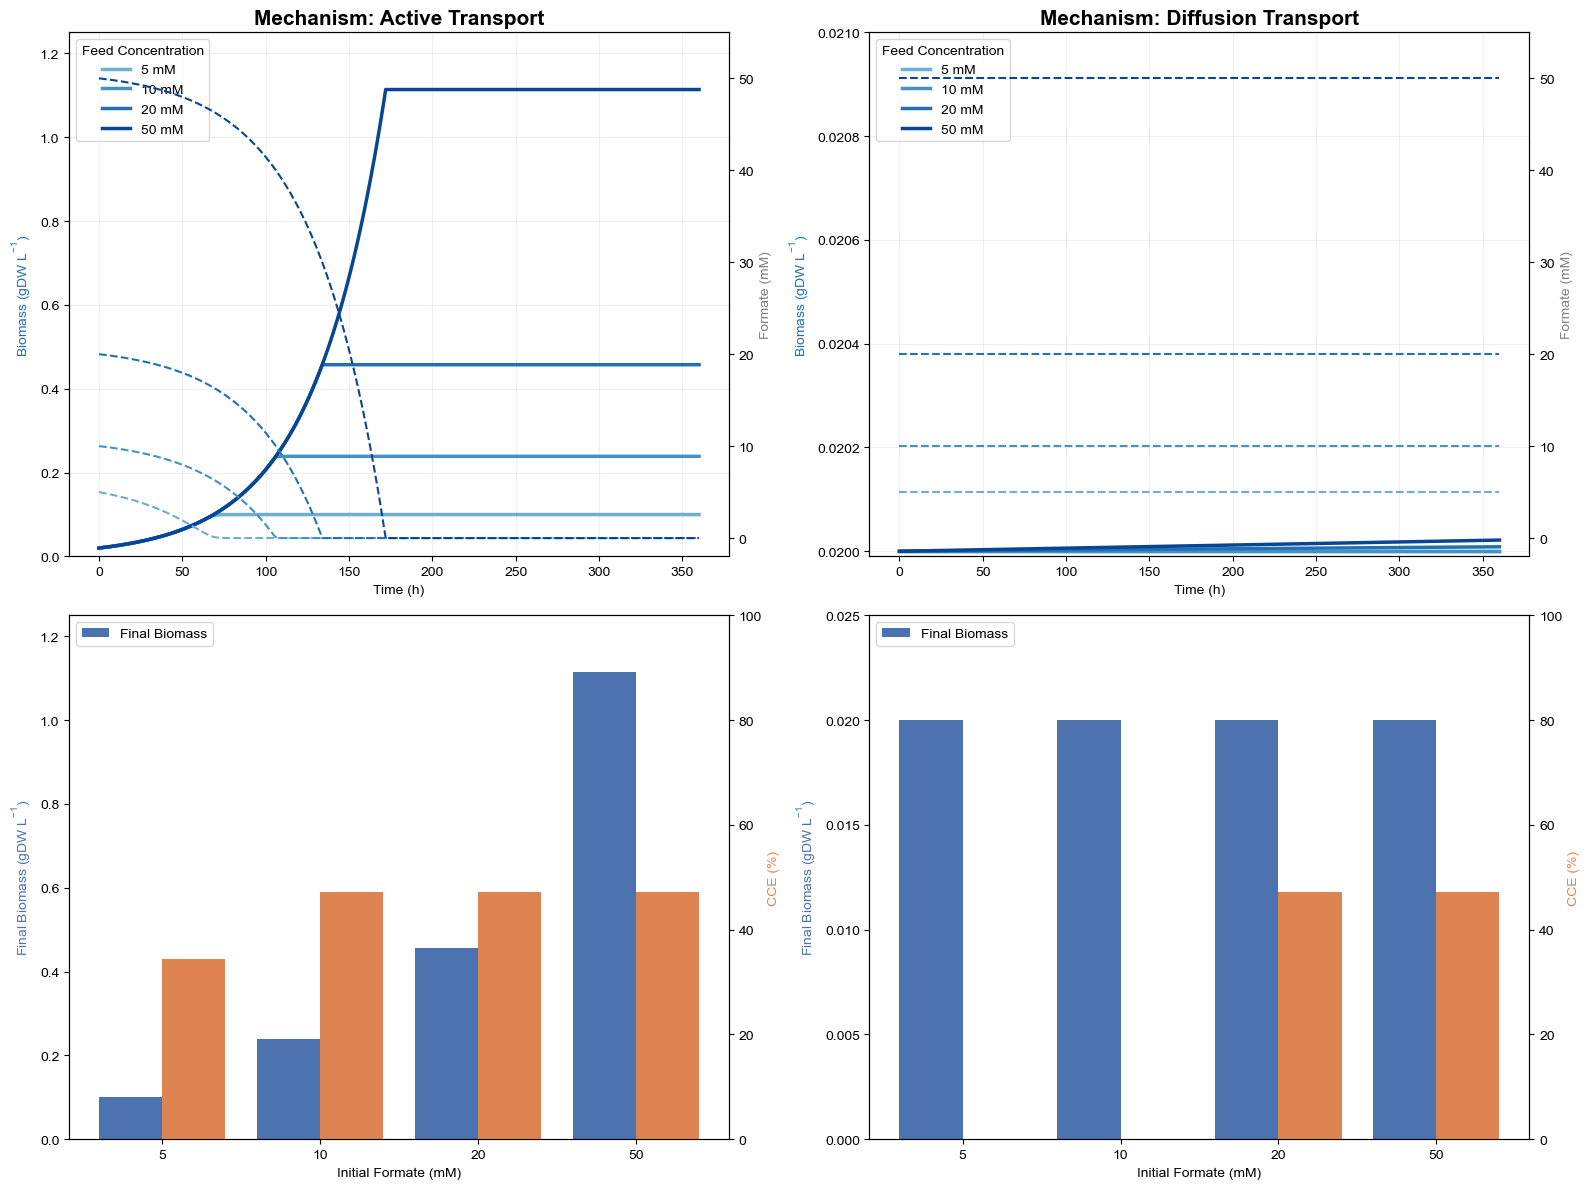

In [10]:
import cobra
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Configure vector font rendering
mpl.rcParams['svg.fonttype'] = 'none'

def apply_base_conditions(model):
    """Apply baseline environmental medium and reaction constraints."""
    for ex in model.exchanges: 
        ex.lower_bound = 0.0
    essential_ions = [
        'EX_cobalt2_e', 'EX_zn2_e', 'EX_so4_e', 'EX_ca2_e', 'EX_mn2_e', 
        'EX_mg2_e', 'EX_cu2_e', 'EX_k_e', 'EX_fe3_e', 'EX_mobd_e',
        'EX_na1_e', 'EX_cl_e', 'EX_bo3_e', 'EX_pi_e', 'EX_h2o_e', 'EX_h_e', 'EX_nh4_e'
    ]
    for ion in essential_ions:
        if ion in model.reactions: 
            model.reactions.get_by_id(ion).lower_bound = -1000.0
    if "EX_co2_e" in model.reactions: model.reactions.get_by_id("EX_co2_e").bounds = (-1000.0, 1000.0) 
    if "EX_o2_e" in model.reactions: model.reactions.get_by_id("EX_o2_e").bounds = (-1.0, 1000.0) 
    if "NTRSA" in model.reactions: model.reactions.get_by_id("NTRSA").bounds = (0, 0.0)
    
    # Set the physical upper bound for growth rate based on experimental observations
    model.reactions.BIOMASS__1.upper_bound = 0.023645071
    
    if "EX_photon_purple_e" in model.reactions: 
        model.reactions.get_by_id("EX_photon_purple_e").bounds = (-1000.0, 0.0) 
    if "POR5" in model.reactions: model.reactions.get_by_id("POR5").lower_bound = 0.0
    if "ME2" in model.reactions: model.reactions.get_by_id("ME2").lower_bound = 0.0
    return model

def run_final_dfba():
    # Load the model
    model = cobra.io.load_json_model("../Models/purple_bacteriav_DSM123.json") 
    model = apply_base_conditions(model)
    model.objective = "BIOMASS__1"

    # ==========================================
    # Core physical parameters based on Nichols (2017) [cite: 1]
    # ==========================================
    t_max, dt = 360, 1.0
    X_0 = 0.02
    initial_formates = [5, 10, 20, 50]
    mechanisms = ["Active", "Diffusion"]
    
    Vmax_limit = 1.786555464      
    Km_ForT = 0.01814     
    Km_fdh = 0.38126      
    
    # Nichols 2017 physical parameters used to model cell envelope resistance [cite: 1]
    P_envelope = 1.0e-8           # Overall envelope permeability coefficient (cm/s)
    Area_spec_nichols = 1.32e5    # Cell-specific surface area (cm2/gDW)
    # Unit conversion: (cm/s * cm2/gDW * 3600s/h) / 1000cm3/L = L/(gDW*h)
    diff_conv = P_envelope * Area_spec_nichols * 3600 / 1000
    
    pKa_formic = 3.75; pH_env = 7.0
    TOTAL_LIGHT = 50.0; MAX_SPECIFIC_LIGHT = 60.0
    # ==========================================

    all_results = {mech: {} for mech in mechanisms}

    # Run the dFBA loop
    for mech in mechanisms:
        for init_for in initial_formates:
            X, For, CO2 = X_0, init_for, 0.0
            history = {"time": [], "X": [], "For": [], "CO2": []}
            
            for t in np.arange(0, t_max + dt, dt):
                if For > 1e-4:
                    if mech == "Active":
                        v_uptake = Vmax_limit * (For / (Km_ForT + For))
                    else:
                        # Only neutral HCOOH is permeable
                        frac_undiss = 1.0 / (1.0 + 10**(pH_env - pKa_formic))
                        v_uptake = diff_conv * (For * frac_undiss)
                else: v_uptake = 0.0

                model.reactions.get_by_id("EX_for_e").lower_bound = -v_uptake
                if "FDH" in model.reactions:
                    v_fdh_max = Vmax_limit * (For / (Km_fdh + For))
                    model.reactions.get_by_id("FDH").upper_bound = min(v_uptake, v_fdh_max)
                
                # Light-shading effect model
                model.reactions.get_by_id("EX_photon_purple_e").lower_bound = -min(MAX_SPECIFIC_LIGHT, TOTAL_LIGHT/X)
                
                sol = model.slim_optimize()
                if sol > 1e-6:
                    full_sol = model.optimize()
                    mu, f_for, f_co2 = full_sol.objective_value, full_sol.fluxes["EX_for_e"], full_sol.fluxes["EX_co2_e"]
                else: mu, f_for, f_co2 = 0.0, 0.0, 0.0
                
                history["time"].append(t); history["X"].append(X)
                history["For"].append(For); history["CO2"].append(CO2)
                
                X += mu * X * dt; For += f_for * X * dt; CO2 += f_co2 * X * dt
                if For < 0: For = 0.0
            all_results[mech][init_for] = history

    # ==========================================
    # Four-panel scientific figure with independently adjustable panel B
    # ==========================================
    plt.rcParams['font.sans-serif'] = ['Arial']; plt.rcParams['axes.unicode_minus'] = False
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    colors = ['#6baed6', '#4292c6', '#2171b5', '#084594'] 
    
    # --- Shared plotting parameters ---
    active_max_biomass = 1.25
    active_max_formate = 55.0

    for row, mech in enumerate(mechanisms):
        # --- Top panels: dynamic profiles (Biomass and Formate) ---
        ax_l = axes[0, row]
        ax_r = ax_l.twinx()
        for i, f in enumerate(initial_formates):
            d = all_results[mech][f]
            ax_l.plot(d["time"], d["X"], color=colors[i], lw=2.5, label=f"{f} mM")
            ax_r.plot(d["time"], d["For"], color=colors[i], ls='--', lw=1.5, alpha=1)
        
        ax_l.set_title(f"Mechanism: {mech} Transport", fontsize=15, fontweight='bold')
        ax_l.set_xlabel("Time (h)"); ax_l.set_ylabel(r"Biomass (gDW L$^{-1}$)", color='#2171b5')
        ax_r.set_ylabel("Formate (mM)", color='gray')
        
        # Set axis ranges separately for Active and Diffusion
        if mech == "Active":
            ax_l.set_ylim(0, active_max_biomass)
            ax_r.set_ylim(-2, active_max_formate)
        else:
            # Adjust the Y-axis range for panel B (Diffusion) here
            # Because diffusion is slow, narrow the range to inspect small changes near 0.02
            ax_l.set_ylim(0.019990, 0.021)  # Inspect small fluctuations near 0.02
            ax_r.set_ylim(-2, 55.0)          # Substrate depletion is minimal; keep or narrow the range
        
        ax_l.grid(True, alpha=0.2); ax_l.legend(title="Feed Concentration", loc='upper left')

        # --- Bottom panels: endpoint statistics (Final Biomass and CCE) ---
        ax_b1 = axes[1, row]
        ax_b2 = ax_b1.twinx()
        
        fx = [all_results[mech][f]["X"][-1] for f in initial_formates]
        cce = []
        for f in initial_formates:
            cons = f - all_results[mech][f]["For"][-1]
            co2 = all_results[mech][f]["CO2"][-1]
            cce.append(((cons - co2) / (cons + 1e-9)) * 100)
            
        x_idx = np.arange(len(initial_formates))
        ax_b1.bar(x_idx - 0.2, fx, 0.4, color='#4c72b0', label='Final Biomass')
        ax_b2.bar(x_idx + 0.2, cce, 0.4, color='#dd8452', label='CCE (%)')
        
        ax_b1.set_ylabel(r"Final Biomass (gDW L$^{-1}$)", color='#4c72b0')
        ax_b2.set_ylabel("CCE (%)", color='#dd8452')
        
        # Axis scaling for the bottom bar plots
        if mech == "Active":
            ax_b1.set_ylim(0, active_max_biomass)
        else:
            ax_b1.set_ylim(0, 0.025)  # The diffusion group has low final biomass
            
        ax_b2.set_ylim(0, 100)
        ax_b1.set_xticks(x_idx); ax_b1.set_xticklabels(initial_formates)
        ax_b1.set_xlabel("Initial Formate (mM)")
        ax_b1.legend(loc='upper left')

    plt.tight_layout()
    output_filename = "dFBA_PurpleBacteria_Nichols_AdjustedAxes.svg"
    plt.savefig(output_filename, format='svg', dpi=300)
    print(f"High-resolution vector figure saved as: {output_filename}")

if __name__ == "__main__":
    run_final_dfba()

